In [1]:
from __future__ import annotations

import torch
from torchvision.models import resnet50
from transformers import ViTForImageClassification

from shapiq.vision.typing import VisionModel, ViTLikeModel

cnn = resnet50(weights=None)
vit = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")

print(isinstance(cnn, VisionModel))
print(isinstance(vit, ViTLikeModel))

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

True
True


In [2]:
isinstance(vit, VisionModel)

True

In [3]:
isinstance(cnn, ViTLikeModel)

False

# Testing ResNet-18

In [1]:
from io import BytesIO

import numpy as np
import requests
from PIL import Image
from torchvision import models, transforms
import torch

# --- load test image ---
# img = "dog.png"
# image = np.array(Image.open(img).convert("RGB").resize((224, 224)))
# print(f"Image shape: {image.shape}")  # expected: (224, 224, 3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
url = "https://images.unsplash.com/photo-1640384974326-3e72680e0fb3?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D" # cat 73%
response = requests.get(url)
raw_img = Image.open(BytesIO(response.content)).convert("RGB")
print("Raw image size:",raw_img.size)

# Resize and crop
resize_and_crop = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224)
])

# Convert to tensor and normalize
tensor_and_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

resized_img = resize_and_crop(raw_img)

# Input image for the model
input_tensor = tensor_and_norm(resized_img)
input_batch = input_tensor.unsqueeze(0).to(device)
print(input_batch.shape)  # expected: (1, 3, 224, 224)

# # --- load resnet-18 ---
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.eval()

with torch.no_grad():
    predicted_class = resnet(input_batch).argmax(dim=1).item()
    print(f"Predicted class index: {predicted_class}")


Raw image size: (687, 1031)
torch.Size([1, 3, 224, 224])
Predicted class index: 281


In [2]:
from shapiq.explainer import Explainer
from shapiq.vision.architecture import CNNArchitecture

ex = Explainer(model=CNNArchitecture(model=resnet), data=resized_img)

In [4]:
interaction_values = ex.explain(budget=46)

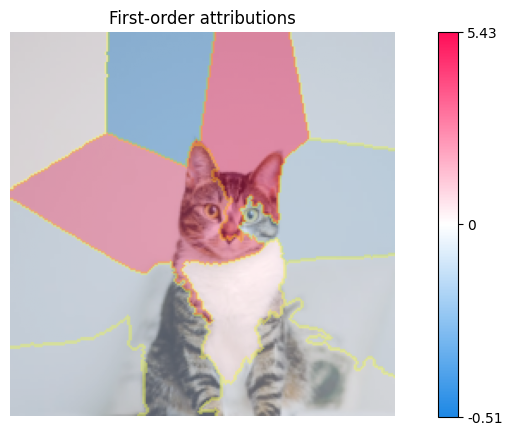

In [6]:
interaction_values.plot_image_attributions(np.array(resized_img), ex.imputer.player_masks)

In [10]:
from shapiq import ImageExplainer, KernelSHAP
from shapiq.vision import CNNArchitecture, ImageImputer
from shapiq.vision.players import GridStrategy

# from skimage.segmentation import slic

# superpixels = slic(np.array(resized_img), n_segments=20, compactness=10, sigma=1)

player_strategy = GridStrategy(grid_shape=20)
image = input_tensor.numpy().transpose(1, 2, 0) # (H, W, C)
model = CNNArchitecture(resnet)
my_resnet = model
# explainer = ImageExplainer(model=model, data=image)


explainer = ImageExplainer(model=my_resnet, data=image)

#interaction_values_resnet = explainer.explain(budget=512)

imputer = ImageImputer(model, image)
approx = KernelSHAP(imputer.n_features)
interaction_values_resnet = approx.approximate(game=imputer, budget=512)

print(f"n_players: {imputer.n_features}")
print(interaction_values_resnet)

n_players: 11
InteractionValues(
    index=SV, max_order=1, min_order=0, estimated=True, estimation_budget=512,
    n_players=11, baseline_value=2.384185791015625e-07,
    Top 10 interactions:
        (6,): 4.007350404968459
        (4,): 3.9864854636001543
        (2,): 2.179865852581741
        (9,): 1.652794875098411
        (5,): 0.993768956682215
        (7,): 0.9442550022618654
        (0,): 0.1342359320075398
        (3,): 0.06555422191637485
        (10,): -0.2476613280067238
        (1,): -0.32908407169219767
)


In [7]:
interaction_values_resnet.plot_image_attributions(
            image=np.array(resized_img),
            explainer=explainer,
            heatmap_only=False,
)

NameError: name 'interaction_values_resnet' is not defined

# Testing ViT

In [1]:
import numpy as np
import torch
from PIL import Image
from transformers import ViTForImageClassification, ViTImageProcessor

# Use patch32-384 to match 12x12 grid (grid_size=12, patch_size=32, image_size=384)
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch32-384")
vit = ViTForImageClassification.from_pretrained("google/vit-base-patch32-384")
vit.eval()

# mask_token is None by default in ViTForImageClassification; MaskTokenStrategy initialises it automatically

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [2]:
from shapiq.vision import ImageExplainer, TransformerArchitecture

# default: PatchStrategy derived from model.config + MaskTokenStrategy (zeroes mask_token)
# use BoolMaskedPosStrategy() instead if the model already has mask_token set (e.g. MAE-pretrained ViT)

image = np.array(resized_img)
# players = PatchStrategy(grid_size=12, n_players=144)  # 12x12 grid for 384x384 image with 32x32 patches
model = TransformerArchitecture(model=vit, vit_processor=processor)

NameError: name 'resized_img' is not defined

In [10]:
from shapiq.vision import ImageExplainer, TransformerArchitecture

# default: PatchStrategy derived from model.config + MaskTokenStrategy (zeroes mask_token)
# use BoolMaskedPosStrategy() instead if the model already has mask_token set (e.g. MAE-pretrained ViT)

image = np.array(resized_img)
model = TransformerArchitecture(model=vit, vit_processor=processor)
explainer = ImageExplainer(model=model, data=image)
interaction_values_vit = explainer.explain(budget=64)

print(f"n_players: {explainer.imputer.n_players}")
print(interaction_values_vit)

n_players: 9
InteractionValues(
    index=SV, max_order=1, min_order=0, estimated=True, estimation_budget=64,
    n_players=9, baseline_value=0.00019532430451363325,
    Top 10 interactions:
        (7,): 0.3660255658398085
        (4,): 0.3327254665966412
        (6,): 0.061184751058621555
        (8,): 0.05417569213572533
        (1,): 0.03482537287411407
        (5,): 0.03302622647576184
        (2,): 0.007989979235004191
        (): 0.00019532430451363325
        (3,): -0.025580069168982235
        (0,): -0.03387935483374424
)


In [21]:
from shapiq.vision.masking import * 
from shapiq.vision.players import *
model = CNNArchitecture(model=resnet, masking_strategy=MaskTokenStrategy(resnet), player_strategy=PatchStrategy(grid_size=12, n_players=144))

TypeError: PatchStrategy requires a model compatible with ViTLikeModel, got ResNet.

In [2]:
class model_without_vit: 
    config = {}
    def __call__(self, pixel_values: torch.Tensor, bool_masked_pos: torch.BoolTensor | None = None, **kwargs) -> torch.Tensor:
        # Implement the forward pass for the model without ViT
        pass
    
dummy = model_without_vit()

In [4]:
from shapiq.vision.masking import * 
from shapiq.vision.players import *
from shapiq.vision.architecture import TransformerArchitecture
model = TransformerArchitecture(model=vit, vit_processor=processor, masking_strategy=MaskTokenStrategy(vit))

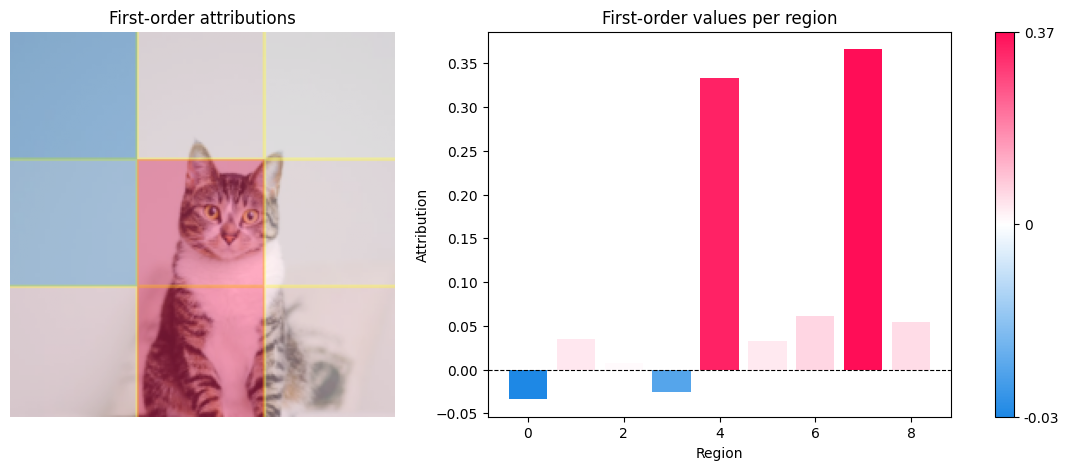

In [12]:
interaction_values_vit.plot_image_attributions(
            image=np.array(resized_img),
            player_masks=explainer.imputer.player_masks,
            heatmap_only=False,
)

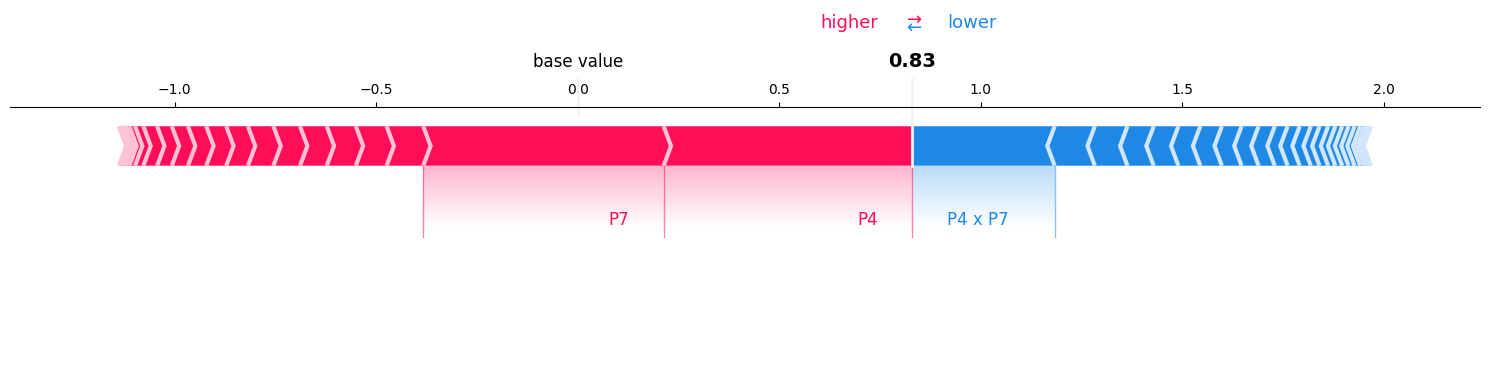

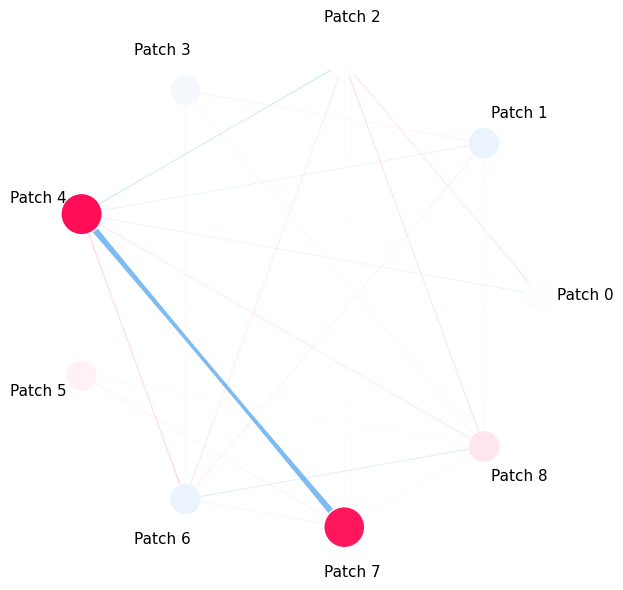

In [ ]:
interaction_values_vit.plot_force(feature_names=[f"Patch {i}" for i in range(explainer.imputer.n_players)])
interaction_values_vit.plot_network(feature_names=[f"Patch {i}" for i in range(explainer.imputer.n_players)])

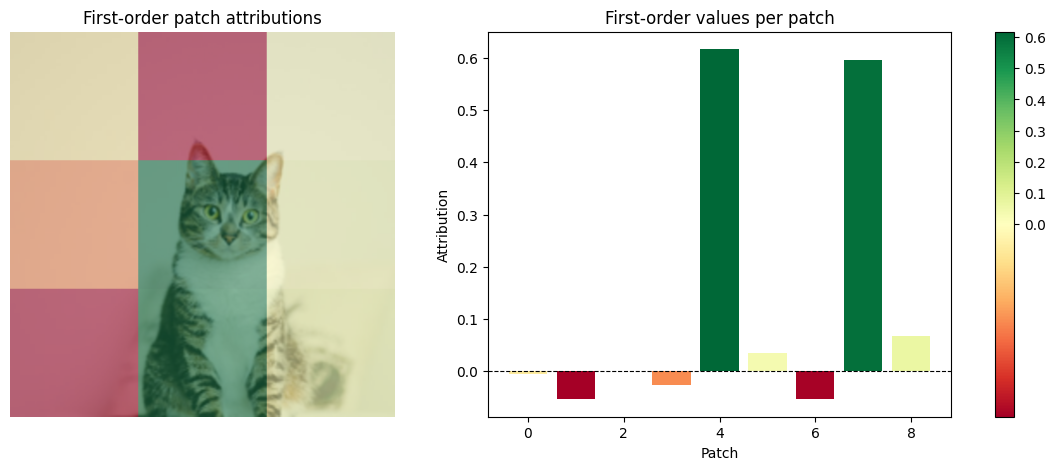

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import cm

# First-order (main effects)
first_order = interaction_values_vit.get_n_order_values(1)

# Rebuild patch grid params (in case this cell runs standalone)
image_size = model.config.image_size
patch_size = model.config.patch_size
grid_size = image_size // patch_size

n_players = explainer.imputer.n_players
side = int(np.sqrt(n_players))
block = grid_size // side

# Build heatmap on patch grid
heatmap_grid = np.zeros((grid_size, grid_size), dtype=float)
for p in range(n_players):
    y = (p // side) * block
    x = (p % side) * block
    heatmap_grid[y : y + block, x : x + block] = first_order[p]

# Upsample to pixel space
heatmap_img = np.kron(heatmap_grid, np.ones((patch_size, patch_size)))

# Resize image for alignment
image_resized = resized_img.resize((image_size, image_size))

# Diverging colormap centered at 0
cmap = cm.RdYlGn
norm = mcolors.TwoSlopeNorm(vmin=heatmap_img.min(), vcenter=0, vmax=heatmap_img.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlay heatmap
axes[0].imshow(image_resized)
axes[0].imshow(heatmap_img, alpha=0.5, cmap=cmap, norm=norm)
axes[0].set_title("First-order patch attributions")
axes[0].axis("off")

# Bar plot
bar_colors = [cmap(norm(v)) for v in first_order]
axes[1].bar(range(n_players), first_order, color=bar_colors)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Patch")
axes[1].set_ylabel("Attribution")
axes[1].set_title("First-order values per patch")

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.04)

plt.show()